# Notebook 04 — Preprocessing & Temporal Clustering

## Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

## Load Feature Datasets

In [2]:
train_feat = pd.read_csv("../data/processed/train_customer_features.csv")
valid_feat = pd.read_csv("../data/processed/valid_customer_features.csv")

print("Train shape:", train_feat.shape)
print("Validation shape:", valid_feat.shape)

Train shape: (4266, 13)
Validation shape: (4297, 13)


In [3]:
train_feat.head()

,Customer ID,first_purchase,last_purchase,frequency,monetary,recency,lifespan,avg_order_value,active_months,avg_purchase_gap,spending_volatility,avg_basket_size,revenue_contribution
0,12346,2009-12-14 08:34:00,2010-06-28 13:53:00,11,372.86,156,196,33.896364,4,19.2,37.302802,6.363636,0.000044
1,12347,2010-10-31 14:20:00,2010-10-31 14:20:00,1,611.53,31,0,611.530000,1,0.0,0.000000,509.000000,0.000072
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,1,222.16,65,0,222.160000,1,0.0,0.000000,373.000000,0.000026
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,2671.14,34,181,890.380000,3,90.0,620.785076,331.000000,0.000315
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,2,0,300.930000,1,0.0,0.000000,261.000000,0.000035


In [4]:
print("Train Null Values:\n")
print(train_feat.isna().sum().sort_values(ascending=False).head(10))

print("\nValidation Null Values:\n")
print(valid_feat.isna().sum().sort_values(ascending=False).head(10))

Train Null Values:

Customer ID         0
first_purchase      0
last_purchase       0
frequency           0
monetary            0
recency             0
lifespan            0
avg_order_value     0
active_months       0
avg_purchase_gap    0
dtype: int64

Validation Null Values:

Customer ID         0
first_purchase      0
last_purchase       0
frequency           0
monetary            0
recency             0
lifespan            0
avg_order_value     0
active_months       0
avg_purchase_gap    0
dtype: int64


In [5]:
print("Train duplicate customers:",
      train_feat["Customer ID"].duplicated().sum())

print("Validation duplicate customers:",
      valid_feat["Customer ID"].duplicated().sum())

Train duplicate customers: 0
Validation duplicate customers: 0


In [6]:
train_feat.describe()

,Customer ID,frequency,monetary,recency,lifespan,avg_order_value,active_months,avg_purchase_gap,spending_volatility,avg_basket_size,revenue_contribution
count,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4.266000e+03
mean,15348.571964,4.321847,1989.586820,88.219409,130.322316,379.687099,2.939756,46.753632,146.259472,257.084034,2.344116e-04
std,1698.485902,7.763641,8599.149266,95.114575,129.552258,506.279065,2.463117,60.769890,402.303947,1562.727090,1.013145e-03
min,12346.000000,1.000000,2.950000,1.000000,0.000000,2.950000,1.000000,0.000000,0.000000,1.000000,3.475668e-07
25%,13885.000000,1.000000,306.595000,16.000000,0.000000,179.027500,1.000000,0.000000,0.000000,89.020833,3.612279e-05
50%,15348.500000,2.000000,681.810000,48.000000,103.000000,288.208750,2.000000,28.125000,64.568262,154.000000,8.033034e-05
75%,16833.750000,5.000000,1662.222500,135.000000,247.000000,424.007500,4.000000,69.000000,167.470793,258.000000,1.958418e-04
max,18287.000000,197.000000,321329.740000,365.000000,364.000000,11880.840000,12.000000,363.000000,13108.029950,87167.000000,3.785883e-02


In [7]:
assert (train_feat["frequency"] >= 1).all()
assert (valid_feat["frequency"] >= 1).all()
assert (train_feat["recency"] >= 0).all()
assert (valid_feat["recency"] >= 0).all()
assert (train_feat["monetary"] > 0).all()
assert (valid_feat["monetary"] > 0).all()

## Define Feature Matrix

In [8]:
drop_cols = ["Customer ID", "first_purchase", "last_purchase"]

X_train = train_feat.drop(columns=drop_cols).copy()
X_valid = valid_feat.drop(columns=drop_cols).copy()

X_train.head()

,frequency,monetary,recency,lifespan,avg_order_value,active_months,avg_purchase_gap,spending_volatility,avg_basket_size,revenue_contribution
0,11,372.86,156,196,33.896364,4,19.2,37.302802,6.363636,0.000044
1,1,611.53,31,0,611.530000,1,0.0,0.000000,509.000000,0.000072
2,1,222.16,65,0,222.160000,1,0.0,0.000000,373.000000,0.000026
3,3,2671.14,34,181,890.380000,3,90.0,620.785076,331.000000,0.000315
4,1,300.93,2,0,300.930000,1,0.0,0.000000,261.000000,0.000035


## Check Distribution & Skewness

In [9]:
X_train.describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,frequency,monetary,recency,lifespan,avg_order_value,active_months,avg_purchase_gap,spending_volatility,avg_basket_size,revenue_contribution
count,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4266.000000,4.266000e+03
mean,4.321847,1989.586820,88.219409,130.322316,379.687099,2.939756,46.753632,146.259472,257.084034,2.344116e-04
std,7.763641,8599.149266,95.114575,129.552258,506.279065,2.463117,60.769890,402.303947,1562.727090,1.013145e-03
min,1.000000,2.950000,1.000000,0.000000,2.950000,1.000000,0.000000,0.000000,1.000000,3.475668e-07
1%,1.000000,40.476000,1.000000,0.000000,33.617636,1.000000,0.000000,0.000000,3.650000,4.768852e-06
5%,1.000000,108.130000,3.000000,0.000000,90.035000,1.000000,0.000000,0.000000,31.000000,1.273980e-05
50%,2.000000,681.810000,48.000000,103.000000,288.208750,2.000000,28.125000,64.568262,154.000000,8.033034e-05
95%,13.000000,6044.747500,296.000000,349.000000,930.198333,8.000000,167.000000,482.862071,585.125000,7.121876e-04
99%,29.350000,19409.682000,359.000000,359.000000,1987.455875,11.000000,289.350000,1195.402860,1320.537366,2.286834e-03
max,197.000000,321329.740000,365.000000,364.000000,11880.840000,12.000000,363.000000,13108.029950,87167.000000,3.785883e-02


In [10]:
X_train.skew().sort_values(ascending=False)

avg_basket_size         46.185980
revenue_contribution    23.285756
monetary                23.285756
spending_volatility     14.953401
avg_order_value         11.482805
frequency               10.153569
avg_purchase_gap         2.006336
active_months            1.615339
recency                  1.277222
lifespan                 0.412856
dtype: float64

## Log Transformation of Skewed Features

The distribution analysis showed extreme positive skew in several behavioral and monetary features.

Because K-Means clustering is distance-based and highly sensitive to magnitude differences, 
we apply a log transformation (`log1p`) to compress heavy-tailed distributions.

The transformation is applied consistently to both training and validation datasets.

In [11]:
skewed_cols = [
    "avg_basket_size",
    "revenue_contribution",
    "monetary",
    "spending_volatility",
    "avg_order_value",
    "frequency",
    "avg_purchase_gap",
    "active_months",
    "recency"
]

In [12]:
skewed_cols = [col for col in skewed_cols if col in X_train.columns]

In [13]:
for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_valid[col] = np.log1p(X_valid[col])

print("Log transformation applied to:", skewed_cols)

Log transformation applied to: ['avg_basket_size', 'revenue_contribution', 'monetary', 'spending_volatility', 'avg_order_value', 'frequency', 'avg_purchase_gap', 'active_months', 'recency']


## Re-check Skewness

In [14]:
print("Skewness After Log Transformation:\n")
print(X_train.skew().sort_values(ascending=False))

Skewness After Log Transformation:

revenue_contribution    23.045712
frequency                1.200255
active_months            0.700695
lifespan                 0.412856
monetary                 0.266235
avg_order_value         -0.080481
avg_purchase_gap        -0.276069
spending_volatility     -0.302467
recency                 -0.369343
avg_basket_size         -0.681233
dtype: float64


In [15]:
X_train = X_train.drop(columns=["revenue_contribution"])
X_valid = X_valid.drop(columns=["revenue_contribution"])

## Removing Revenue Contribution from Clustering Features

Although revenue_contribution is a meaningful business metric, 
it remains highly skewed even after log transformation and is 
strongly correlated with monetary value.

Since clustering is distance-based and sensitive to extreme distributions, 
this feature is excluded from the modeling feature matrix to improve 
cluster stability and avoid redundancy.

## Correlation Heatmap

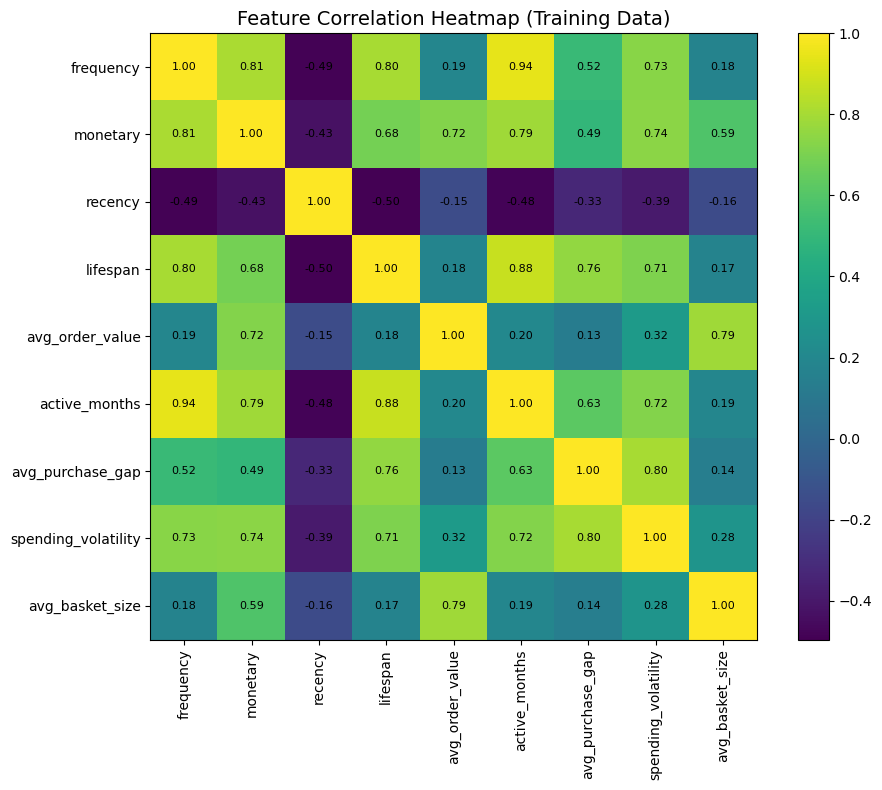

In [16]:
corr_matrix = X_train.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Add numbers inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=8)

plt.title("Feature Correlation Heatmap (Training Data)", fontsize=14)
plt.tight_layout()
plt.show()

## Removing Active Months Due to High Correlation

The correlation analysis revealed a very strong relationship 
between `frequency` and `active_months` (correlation = 0.94).

Since both variables capture similar engagement behavior, 
retaining both would introduce redundancy and distort clustering geometry.

`frequency` is retained as the primary engagement metric, 
and `active_months` is removed from the clustering feature set.

In [17]:
if "active_months" in X_train.columns:
    X_train = X_train.drop(columns=["active_months"])
    X_valid = X_valid.drop(columns=["active_months"])

print("Remaining features:")
print(X_train.columns)

Remaining features:
Index(['frequency', 'monetary', 'recency', 'lifespan', 'avg_order_value',
       'avg_purchase_gap', 'spending_volatility', 'avg_basket_size'],
      dtype='object')


## Feature Scaling

Since K-Means clustering is distance-based, 
all features must be standardized to ensure equal contribution.

The scaler is fit on the training dataset only 
to maintain temporal integrity and avoid data leakage.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("Scaled shapes:", X_train_scaled.shape, X_valid_scaled.shape)

Scaled shapes: (4266, 8) (4297, 8)


## Determining Optimal Number of Clusters (Without PCA)

We first evaluate cluster performance on the scaled feature space 
before applying dimensionality reduction.

This ensures that PCA is used only if it provides measurable improvement 
in separation or stability.

In [19]:
ks = range(2, 11)
inertias = []
sil_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_train_scaled)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels))


### Plot Elbow

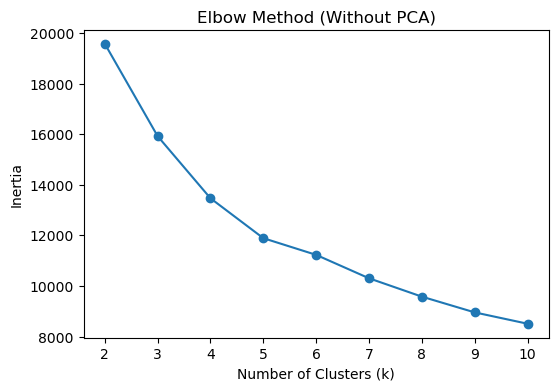

In [20]:
plt.figure(figsize=(6,4))
plt.plot(ks, inertias, marker='o')
plt.title("Elbow Method (Without PCA)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

### Plot Silhouette

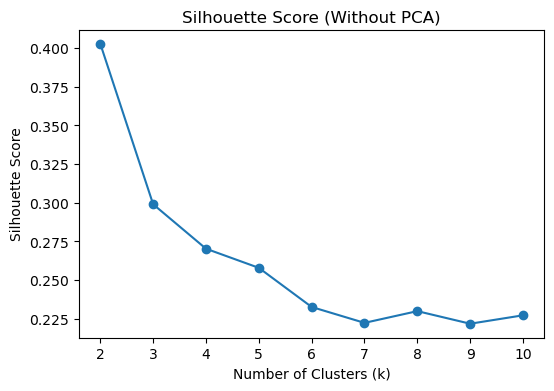

In [21]:
plt.figure(figsize=(6,4))
plt.plot(ks, sil_scores, marker='o')
plt.title("Silhouette Score (Without PCA)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [22]:
print("Silhouette Scores:")
for k, score in zip(ks, sil_scores):
    print(f"k={k}: {score:.4f}")

Silhouette Scores:
k=2: 0.4029
k=3: 0.2990
k=4: 0.2703
k=5: 0.2579
k=6: 0.2326
k=7: 0.2223
k=8: 0.2299
k=9: 0.2217
k=10: 0.2272


## Evaluating Clustering Performance with PCA

To determine whether dimensionality reduction improves cluster separation,
we apply PCA (retaining 90% of explained variance) to the scaled training data.

We then evaluate cluster quality using the Elbow method and Silhouette scores,
and compare the results against the original (non-PCA) feature space.

In [23]:
pca = PCA(n_components=0.90, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_valid_pca = pca.transform(X_valid_scaled)

print("Original dimensions:", X_train_scaled.shape[1])
print("Reduced dimensions after PCA:", X_train_pca.shape[1])
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Original dimensions: 8
Reduced dimensions after PCA: 4
Total explained variance: 0.931


In [24]:
ks = range(2, 11)
inertias_pca = []
sil_scores_pca = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_train_pca)
    
    inertias_pca.append(kmeans.inertia_)
    sil_scores_pca.append(silhouette_score(X_train_pca, labels))



### Elbow Plot (PCA)

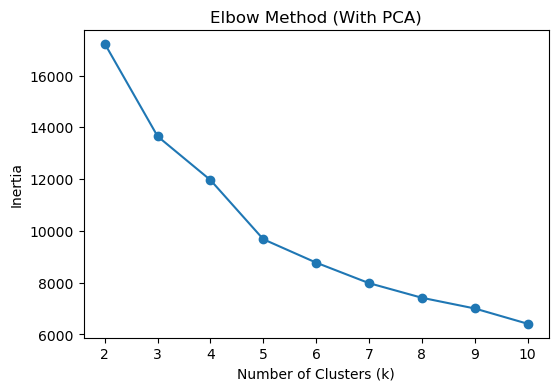

In [25]:
plt.figure(figsize=(6,4))
plt.plot(ks, inertias_pca, marker='o')
plt.title("Elbow Method (With PCA)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

### Silhouette Plot (PCA)

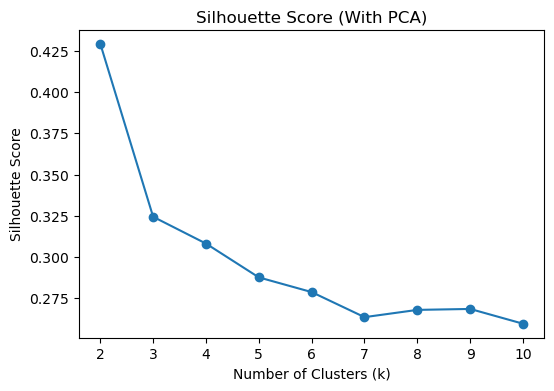

In [26]:
plt.figure(figsize=(6,4))
plt.plot(ks, sil_scores_pca, marker='o')
plt.title("Silhouette Score (With PCA)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()


In [27]:
print("Silhouette Scores (With PCA):")
for k, score in zip(ks, sil_scores_pca):
    print(f"k={k}: {score:.4f}")

Silhouette Scores (With PCA):
k=2: 0.4293
k=3: 0.3244
k=4: 0.3081
k=5: 0.2876
k=6: 0.2787
k=7: 0.2635
k=8: 0.2679
k=9: 0.2685
k=10: 0.2595


## Final Clustering Strategy Selection

Clustering performance was evaluated both with and without PCA using the Elbow method and Silhouette scores.

Although PCA slightly improved silhouette values, the improvement was marginal and reduced feature interpretability. 
Since the original feature space is low-dimensional (8 features) and already well-engineered, 
the non-PCA version was selected to preserve direct business interpretability.

Regarding the number of clusters, the Elbow plot showed a clearer bend at **k = 5**, 
while silhouette scores remained reasonably stable between k = 4 and k = 5. 

To balance mathematical separation and business granularity, 
**k = 5 was selected as the optimal number of clusters**.

## KMeans Baseline (k=5)

We fit KMeans using the selected feature space (no PCA) and k=5.
This serves as a scalable baseline for customer segmentation.

In [28]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels_km_train = kmeans.fit_predict(X_train_scaled)
labels_km_valid = kmeans.predict(X_valid_scaled)

sil_km = silhouette_score(X_train_scaled, labels_km_train)
print(f"KMeans silhouette (train, k={k}): {sil_km:.4f}")

KMeans silhouette (train, k=5): 0.2579


## Hierarchical Clustering Comparison (Ward, k=5)

To validate robustness, we compare KMeans against Agglomerative (Ward linkage)
using the same preprocessed feature space and k=5.

In [30]:
agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_hc_train = agg.fit_predict(X_train_scaled)

sil_hc = silhouette_score(X_train_scaled, labels_hc_train)
print(f"Hierarchical (Ward) silhouette (train, k={k}): {sil_hc:.4f}")

Hierarchical (Ward) silhouette (train, k=5): 0.2145


## Final Algorithm Selection

KMeans and Hierarchical (Ward) clustering were compared using k = 5.

KMeans achieved a higher silhouette score (0.2579) compared to 
Hierarchical clustering (0.2145).

Additionally, KMeans allows direct assignment of new data points 
via centroid-based prediction, making it more suitable for temporal 
validation and potential deployment.

Therefore, KMeans (k = 5) is selected as the final clustering model.

## Create Final Clustered Datasets

In [31]:
train_final = train_feat.copy()
valid_final = valid_feat.copy()

train_final["cluster"] = labels_km_train
valid_final["cluster"] = labels_km_valid

## Save Final Outputs

In [32]:
train_final.to_csv("../data/processed/train_clustered.csv", index=False)
valid_final.to_csv("../data/processed/valid_clustered.csv", index=False)

## Notebook 04 – Clustering & Model Selection Summary

In this notebook, customer-level features were prepared for clustering and evaluated using a structured modeling workflow.

### Key Steps Performed

- Applied log transformation to reduce extreme skewness
- Removed highly correlated features to avoid redundancy
- Standardized all features using training-set statistics
- Compared clustering performance:
  - Without PCA
  - With PCA
- Evaluated optimal number of clusters using:
  - Elbow method
  - Silhouette scores
- Compared algorithms:
  - KMeans
  - Hierarchical (Ward linkage)

### Final Model Selection

Although PCA slightly improved silhouette scores, the improvement was marginal and reduced feature interpretability.  
Given the already well-structured and low-dimensional feature space, clustering was performed **without PCA**.

Between the evaluated algorithms, **KMeans (k = 5)** achieved better separation than Hierarchical clustering and allows consistent assignment of validation data via centroid-based prediction.

Therefore, **KMeans with k = 5** was selected as the final segmentation model.

Cluster labels were assigned to both training and validation datasets and saved for further analysis.

---

This concludes the clustering stage.  
The next step (Notebook 05) will focus on:

- Cluster profiling and interpretation  
- Temporal stability analysis  
- Customer migration between segments  
- Business insights and strategic recommendations